In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Wholesale customers data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Channel', 'Region'], drop_first=True)
display(df_encoded.head())

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_2,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,True,False,True
1,7057,9810,9568,1762,3293,1776,True,False,True
2,6353,8808,7684,2405,3516,7844,True,False,True
3,13265,1196,4221,6404,507,1788,False,False,True
4,22615,5410,7198,3915,1777,5185,True,False,True


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features
df_scaled = scaler.fit_transform(df_encoded)

# Convert the scaled data back to a DataFrame for better readability
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

display(df_scaled.head())

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_2,Region_2,Region_3
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,1.448652,-0.345822,0.626422
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,1.448652,-0.345822,0.626422
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,1.448652,-0.345822,0.626422
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,-0.690297,-0.345822,0.626422
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,1.448652,-0.345822,0.626422


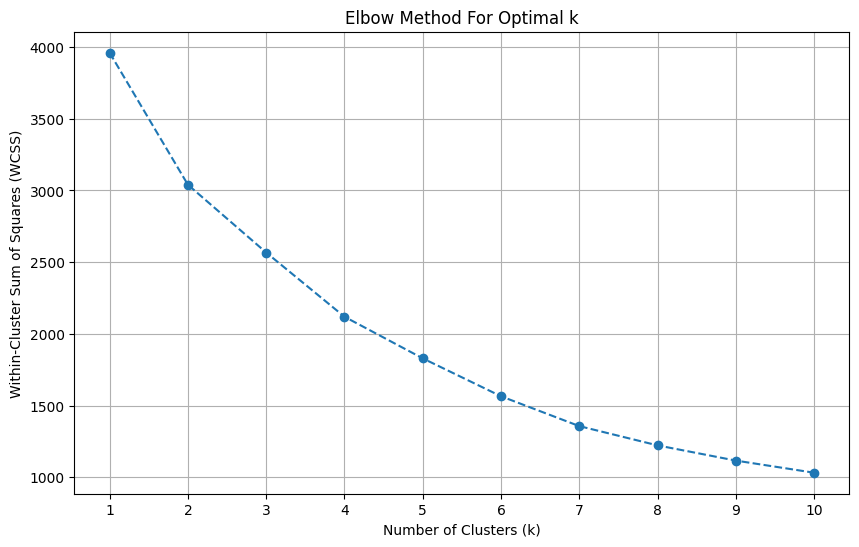

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] # Within-cluster sum of squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Apply K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster labels to the original DataFrame
df['Cluster'] = clusters

# Display the first few rows with the new 'Cluster' column
display(df.head())

# Also display the count of observations in each cluster
display(df['Cluster'].value_counts().sort_index())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


,count
Cluster,
0,276
1,46
2,118


In [ ]:
# Calculate the mean of each feature for each cluster
cluster_means = df.groupby('Cluster').mean()

# Display the cluster means
display(cluster_means)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.025362,2.557971,13759.155797,3429.938406,3902.452899,3427.623188,832.612319,1274.891304
1,1.391304,2.000000,9916.434783,5090.521739,7956.000000,4130.456522,2939.326087,1158.500000
2,1.991525,2.720339,8698.711864,11606.186441,17419.567797,1827.330508,7651.245763,2252.389831


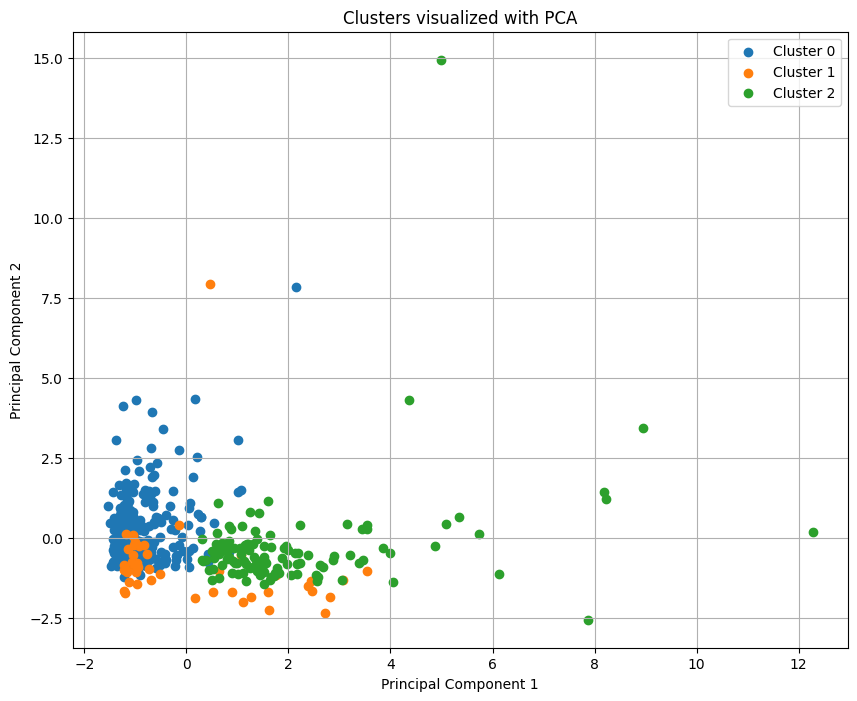

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results with cluster labels
df_pca = pd.DataFrame(data = df_pca, columns = ['PC1', 'PC2'])
df_pca['Cluster'] = clusters

# Plot the clusters
plt.figure(figsize=(10, 8))
for cluster_id in sorted(df_pca['Cluster'].unique()):
    plt.scatter(df_pca.loc[df_pca['Cluster'] == cluster_id, 'PC1'],
                df_pca.loc[df_pca['Cluster'] == cluster_id, 'PC2'],
                label = f'Cluster {cluster_id}')

plt.title('Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

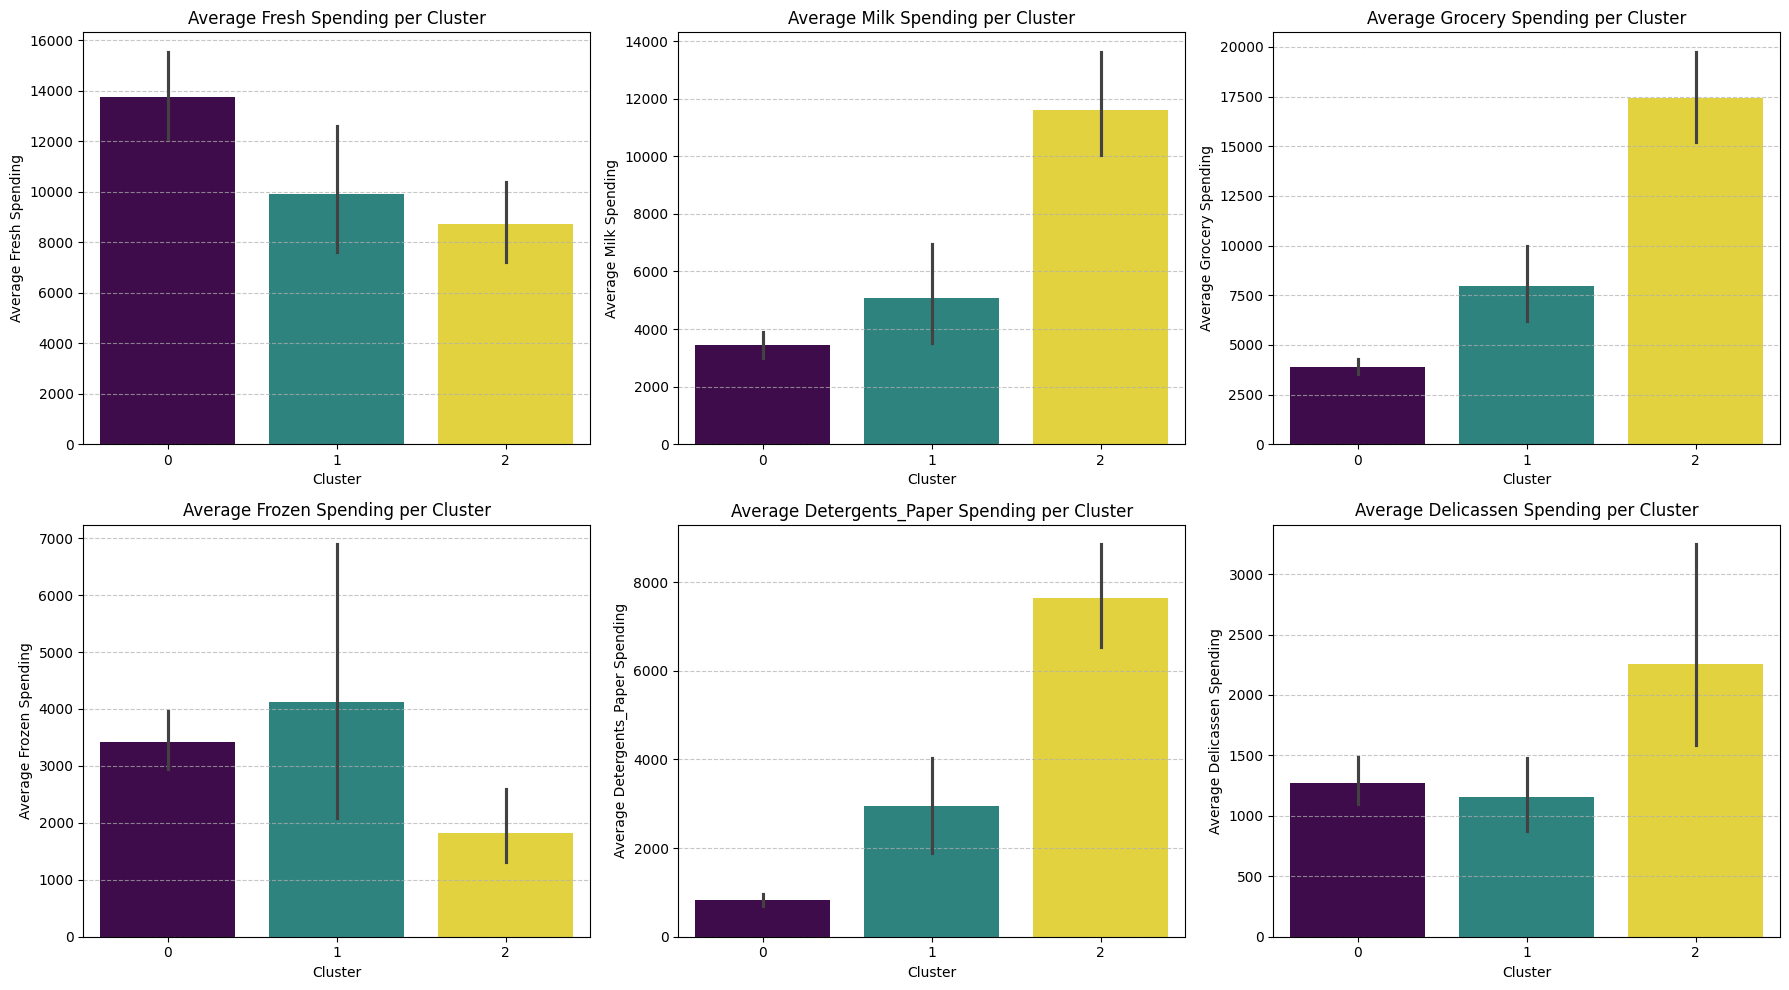

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the product spending columns (excluding 'Channel', 'Region', 'Cluster')
product_columns = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Plot the average spending for each product category per cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(product_columns):
    sns.barplot(x='Cluster', y=col, data=df, ax=axes[i], palette='viridis', hue='Cluster', legend=False)
    axes[i].set_title(f'Average {col} Spending per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(f'Average {col} Spending')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()